In [21]:
import numpy as np
import pandas_ta as ta
import pandas as pd
from matplotlib import pyplot as plt

In [22]:
#Define Variables
Fast_MA = 5
Slow_MA = 6
MA = 200


In [ ]:
#Create DataFrame
data = pd.read_csv("QQQM.csv")
data["Date"] = pd.to_datetime(data["Date"])

data["Fast_MA"] = data.Close.rolling(window = Fast_MA).mean()
data["Slow_MA"] = data.Close.rolling(window = Slow_MA).mean()
data["200_MA"] = data.Close.rolling(window = MA).mean()


            Date     Open     High      Low    Close        Volume
0     2020-10-14  119.959  120.338  118.006  118.604  3.824764e+04
1     2020-10-15  116.691  117.917  116.443  117.748  3.095210e+04
2     2020-10-16  118.534  119.042  117.150  117.150  5.155470e+04
3     2020-10-19  118.464  118.464  114.909  115.127  5.122542e+04
4     2020-10-20  115.577  116.741  114.969  115.567  5.034196e+04
...          ...      ...      ...      ...      ...           ...
1460  2026-08-10  297.455  298.380  296.590  296.850  4.003582e+06
1461  2026-08-11  297.820  297.820  294.770  295.830  2.357081e+06
1462  2026-08-12  299.400  299.430  297.665  297.980  2.183860e+06
1463  2026-08-13  298.570  302.200  298.115  301.410  2.206798e+06
1464  2026-08-14  302.010  302.350  299.880  301.010  1.987537e+06

[1465 rows x 6 columns]


In [40]:
"""plt.figure(figsize=(20,15))
plt.plot(data["Close"])
plt.title("QQQM Closing Price", fontsize = 40)"""

'plt.figure(figsize=(20,15))\nplt.plot(data["Close"])\nplt.title("QQQM Closing Price", fontsize = 40)'

In [41]:
#Calculate daily returns
"""data["Return"] = data.Close / data.Close.shift(1)
data.loc[data.index[0], "Return"] = 1 
data["Bench_Balance"] = starting_balance * data.Return.cumprod()"""

'data["Return"] = data.Close / data.Close.shift(1)\ndata.loc[data.index[0], "Return"] = 1 \ndata["Bench_Balance"] = starting_balance * data.Return.cumprod()'

In [42]:
atr_multiplier = 3
tp_ratio = 1

data["ATR"] = data.ta.atr(length=14)
data["Previous_ATR"] = data["ATR"].shift(1)


data["PDFast_MA"] = data["Fast_MA"].shift(1)
data["PDSlow_MA"] = data["Slow_MA"].shift(1)

data["Signal"] = 0
for i, row in data.iterrows():
    if (row["Fast_MA"] > row["Slow_MA"]) & (row["PDFast_MA"] < row["PDSlow_MA"]):
        data.loc[i, "Signal"] = 1
    """elif (row["Fast_MA"] < row["Slow_MA"]) & (row["PDFast_MA"] > row["PDSlow_MA"]):
        data.loc[i, "Signal"] = 2"""


data["Trade"] = data["Signal"].shift(1).fillna(0)

data['SL'] = None
data["TP"] = None

for i, row in data.iterrows():
    if row.Trade == 1:
        data.loc[i, "SL"] = row.Open - row.Previous_ATR * atr_multiplier
        stop_size = row.Open - data.loc[i, "SL"]
        data.loc[i, "TP"] = row.Open + stop_size * tp_ratio
    elif row.Trade == 2:
        data.loc[i, "SL"] = row.Open + row.Previous_ATR * atr_multiplier
        stop_size = data.loc[i, "SL"] - row.Open
        data.loc[i, "TP"] = row.Open - stop_size * tp_ratio       

##------------------------------------------------------------
#200MA filter
data2 = data.copy()


data2["Signal"] = 0
for i, row in data2.iterrows():
    if (row["Fast_MA"] > row["Slow_MA"]) & (row["PDFast_MA"] < row["PDSlow_MA"]):
        data2.loc[i, "Signal"] = 1
    elif (row["Fast_MA"] < row["Slow_MA"]) & (row["PDFast_MA"] > row["PDSlow_MA"]):
        data2.loc[i, "Signal"] = 2

data2["Trade"] = data2["Signal"].shift(1).fillna(0)

data2.loc[(data2["Trade"] == 1) & (data2["Open"] <= data2["200_MA"]), "Trade"] = 0
data2.loc[(data2["Trade"] == 2) & (data2["Open"] >= data2["200_MA"]), "Trade"] = 0

data2['SL'] = None
data2["TP"] = None

for i, row in data2.iterrows():
    if row.Trade == 1:
        data2.loc[i, "SL"] = row.Open - row.Previous_ATR * atr_multiplier
        stop_size = row.Open - data2.loc[i, "SL"]
        data2.loc[i, "TP"] = row.Open + stop_size * tp_ratio
    elif row.Trade == 2:
        data2.loc[i, "SL"] = row.Open + row.Previous_ATR * atr_multiplier
        stop_size = data2.loc[i, "SL"] - row.Open
        data2.loc[i, "TP"] = row.Open - stop_size * tp_ratio 


print((data2["Trade"] > 0).sum())

182


In [43]:
#Fast & Slow MA Cross

balance = 25000
balance_history =[]

trades_list = []
trade_open = False

risk_per_trade =  0.01

#Iterate through data
for i, row in data.iterrows():
    if not trade_open:
        #Generate trade
        if row.Trade == 1 and pd.notna(row.SL) and pd.notna(row.TP):
            entry_date = row.Date
            entry_price = row.Open
            sl = row.SL
            tp = row.TP
            #Calculate position size based on risk percentage
            risk_amount = balance * risk_per_trade
            position_size = risk_amount/ (entry_price - sl)
            trade_direction = 1
            trade_open = True
        elif row.Trade == 2 and pd.notna(row.SL) and pd.notna(row.TP):
            entry_date = row.Date
            entry_price = row.Open
            sl = row.SL
            tp = row.TP
            #Calculate position size based on risk percentage
            risk_amount = balance * risk_per_trade
            position_size = risk_amount/ (sl - entry_price)
            trade_direction = 2
            trade_open = True           
    #Monitor open trade
    if trade_open == True:
        low = row.Low
        high = row.High

        if trade_direction == 1:
            #Long position
            #Check stop loss      
            if low <= sl:
                if row.Open <= sl:
                    exit_price = row.Open
                else:
                    exit_price = sl
                trade_open = False

            #Check take profit
            elif high >= tp:
                if row.Open >= tp:
                    exit_price = row.Open
                else:
                    exit_price = tp
                trade_open = False
        elif trade_direction == 2:
            #Short position 
            #Check stop loss
            if high >= sl:
                if row.Open >= sl:
                    exit_price = row.Open
                else:
                    exit_price = sl
                trade_open = False

            #Check take profit
            elif low <= tp:
                if row.Open <= tp:
                    exit_price = row.Open
                else:
                    exit_price = tp
                trade_open = False            

        #Process closed trade
        if not trade_open:
            exit_date = row.Date 
            if trade_direction == 1:
                pnl = (exit_price - entry_price) * position_size
            elif trade_direction == 2:
                pnl = (entry_price - exit_price) * position_size
            balance += pnl

            #Store trade data in a list
            trade = [entry_date, entry_price, exit_date, exit_price, trade_direction, position_size, pnl, balance]
            trades_list.append(trade)
    #Track balance
    balance_history.append(balance)

print(len(trades_list))

61


In [44]:
#Fast & Slow MA Cross w/ 200MA Filter

balance2 = 25000
balance_history2 =[]

trades_list2 = []
trade_open2 = False

#Iterate through data
for i, row in data2.iterrows():
    if not trade_open2:
        #Generate trade
        if row.Trade == 1 and pd.notna(row.SL) and pd.notna(row.TP):
            entry_date = row.Date
            entry_price = row.Open
            sl = row.SL
            tp = row.TP
            #Calculate position size based on risk percentage
            risk_amount = balance2 * risk_per_trade
            position_size = risk_amount/ (entry_price - sl)
            trade_direction = 1
            trade_open2 = True
        elif row.Trade == 2 and pd.notna(row.SL) and pd.notna(row.TP):
            entry_date = row.Date
            entry_price = row.Open
            sl = row.SL
            tp = row.TP
            #Calculate position size based on risk percentage
            risk_amount = balance2 * risk_per_trade
            position_size = risk_amount/ (sl - entry_price)
            trade_direction = 2
            trade_open2 = True           
    #Monitor open trade
    if trade_open2 == True:
        low = row.Low
        high = row.High

        if trade_direction == 1:
            #Long position
            #Check stop loss      
            if low <= sl:
                if row.Open <= sl:
                    exit_price = row.Open
                else:
                    exit_price = sl
                trade_open2 = False

            #Check take profit
            elif high >= tp:
                if row.Open >= tp:
                    exit_price = row.Open
                else:
                    exit_price = tp
                trade_open2 = False
        elif trade_direction == 2:
            #Short position 
            #Check stop loss
            if high >= sl:
                if row.Open >= sl:
                    exit_price = row.Open
                else:
                    exit_price = sl
                trade_open2 = False

            #Check take profit
            elif low <= tp:
                if row.Open <= tp:
                    exit_price = row.Open
                else:
                    exit_price = tp
                trade_open2 = False            

        #Process closed trade
        if not trade_open2:
            exit_date = row.Date 
            if trade_direction == 1:
                pnl = (exit_price - entry_price) * position_size
            elif trade_direction == 2:
                pnl = (entry_price - exit_price) * position_size
            balance2 += pnl

            #Store trade data in a list
            trade2 = [entry_date, entry_price, exit_date, exit_price, trade_direction, position_size, pnl, balance2]
            trades_list2.append(trade2)
    #Track balance
    balance_history2.append(balance2)

print(len(trades_list2))


62


In [45]:
trades = pd.DataFrame(trades_list, columns = ["Entry_Date", "Entry_Price", "Exit_Date", "Exit_Price", "Trade_Direction", "Position_Size", "PnL", "Balance"])
trades2 = pd.DataFrame(trades_list2, columns = ["Entry_Date", "Entry_Price", "Exit_Date", "Exit_Price", "Trade_Direction", "Position_Size", "PnL", "Balance"])

trades2

,Entry_Date,Entry_Price,Exit_Date,Exit_Price,Trade_Direction,Position_Size,PnL,Balance
0,2020-11-05,119.142,2020-12-28,127.180000,1,31.445914,252.762255,25252.762255
1,2020-12-29,127.828,2021-01-21,132.577789,1,53.166074,252.527623,25505.289878
2,2021-01-29,130.229,2021-02-10,136.322237,2,41.858356,-255.052899,25250.236979
3,2021-02-22,132.968,2021-02-25,127.429734,2,45.592314,252.502370,25502.739349
4,2021-03-05,125.168,2021-04-05,133.455773,1,30.771523,255.027393,25757.766742
...,...,...,...,...,...,...,...,...
57,2025-12-23,254.480,2026-03-19,242.700000,1,25.475153,-300.097304,29219.955407
58,2026-03-24,240.750,2026-04-13,253.708160,2,22.549464,-292.199554,28927.755853
59,2026-05-20,290.420,2026-05-29,303.810000,1,21.721121,290.845815,29218.601668
60,2026-06-15,303.930,2026-07-17,284.765000,1,15.812869,-303.053635,28915.548033


1465 1465


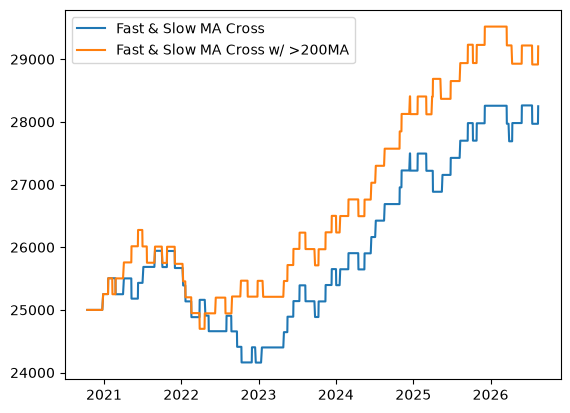

In [ ]:
plt.plot(data.Date, balance_history, label = "Fast & Slow MA Cross")
plt.plot(data.Date, balance_history2, label = "Fast & Slow MA Cross w/ >200MA")
plt.legend()